# **OBJECTIVE**
Conducting Exploratory Data Analysis (EDA) on a dataset containing information about university students. 
The objective is to uncover insights and patterns related to academic performance, study habits, and extracurricular activities.

### What is EDA?
Exploratory Data Analysis (EDA) is an approach used in Data Science to analyze and understand a dataset before applying formal models or making decisions.

## Step 1: Data Collection and Loading
Obtain the dataset (students_performance.csv).

Load the dataset using a data manipulation library such as Pandas in Python.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df=pd.read_csv(r"C:\Users\AKANKSHA\OneDrive\Pictures\Screenshots\MentiBy\Projects\EDAProject\DataSet StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.describe(include="all")

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000


## Step 2: Data Cleaning
Check for missing values and handle them appropriately.

Correct any inconsistencies in the data.

Ensure all data types are appropriate.

 | Method         | Meaning                   |
 | -------------- | ------------------------- |
 | `df.ffill()`   | Fill using previous value |
 | `df.bfill()`   | Fill using next value     |
 | `df.fillna(0)` | Fill with 0               |

In [13]:
df.isnull().sum()
df.ffill(inplace=True)
print(df.dtypes)

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object


## Step 3: Data Transformation
Encode categorical variables.

Normalize or standardize numerical variables if needed.

In [14]:
# df['Gender']=df['Gender'].map({'Male': 0,
#               'Female': 1
#               })

df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})


## Step 4: Data Visualization
Use visualizations to understand the distribution and relationships between variables.
Create histograms, box plots, scatter plots, bar charts, and heatmaps.

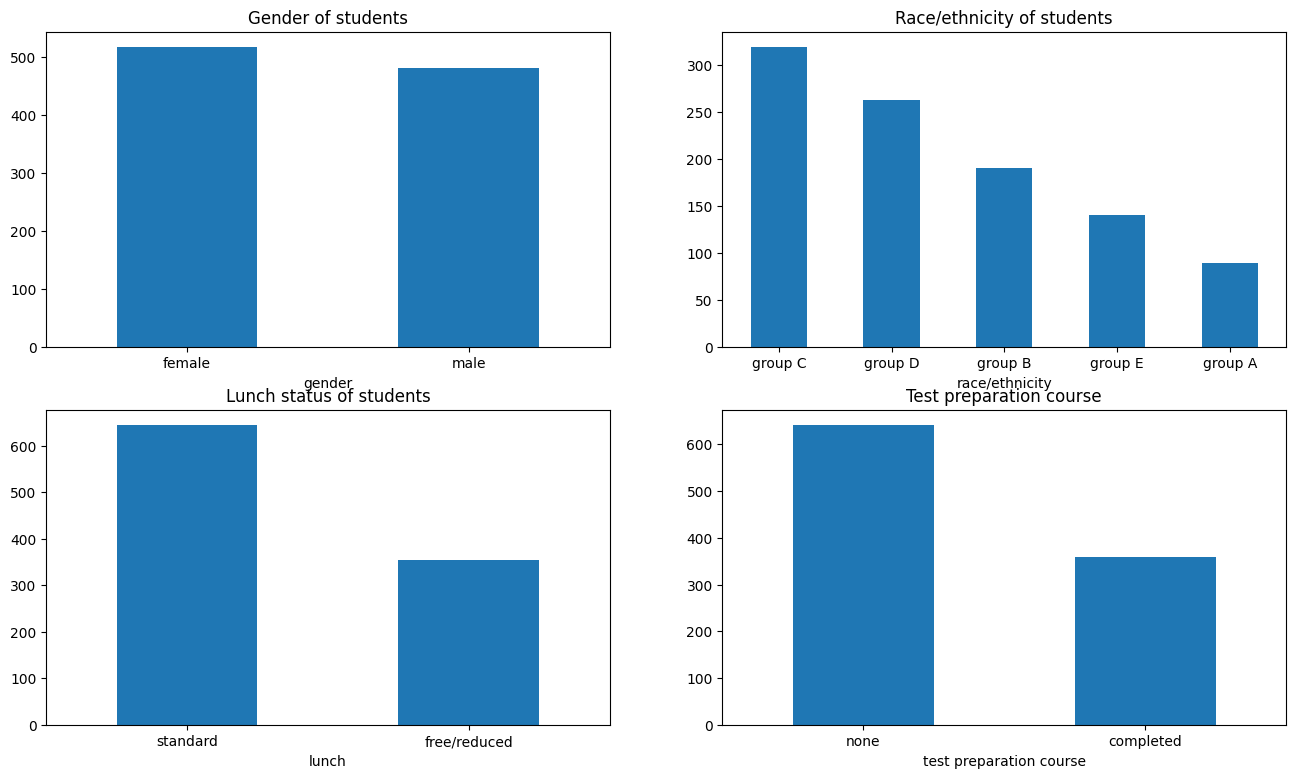

In [3]:
df=pd.read_csv(r"C:\Users\AKANKSHA\OneDrive\Pictures\Screenshots\MentiBy\Projects\EDAProject\DataSet StudentsPerformance.csv")
plt.subplot(221)
df['gender'].value_counts().plot(kind='bar',title='Gender of students',figsize=(16,9))
plt.xticks(rotation=0)
plt.subplot(222)
df['race/ethnicity'].value_counts().plot(kind='bar',title='Race/ethnicity of students')
plt.xticks(rotation=0)
plt.subplot(223)
df['lunch'].value_counts().plot(kind='bar',title='Lunch status of students')
plt.xticks(rotation=0)
plt.subplot(224)
df['test preparation course'].value_counts().plot(kind='bar',title='Test preparation course')
plt.xticks(rotation=0)
plt.show()

<Axes: >

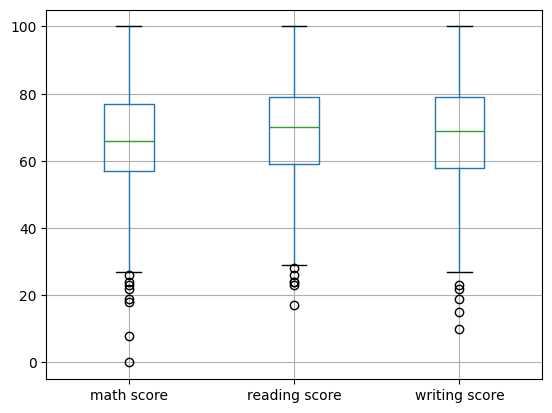

In [20]:
df.boxplot()

C:\Users\AKANKSHA\AppData\Local\Temp\ipykernel_28392\2354272343.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['math score'])


<Axes: xlabel='math score', ylabel='Density'>

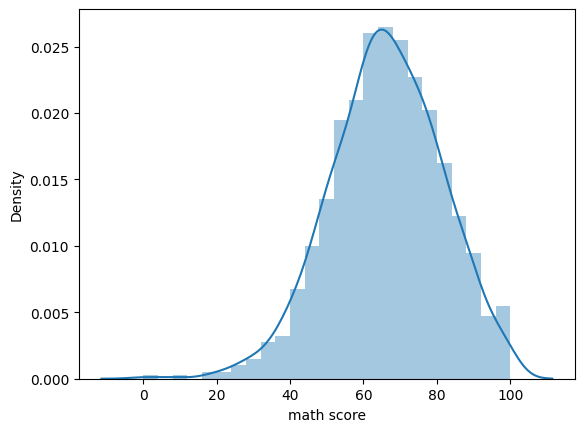

In [22]:
sns.distplot(df['math score'])

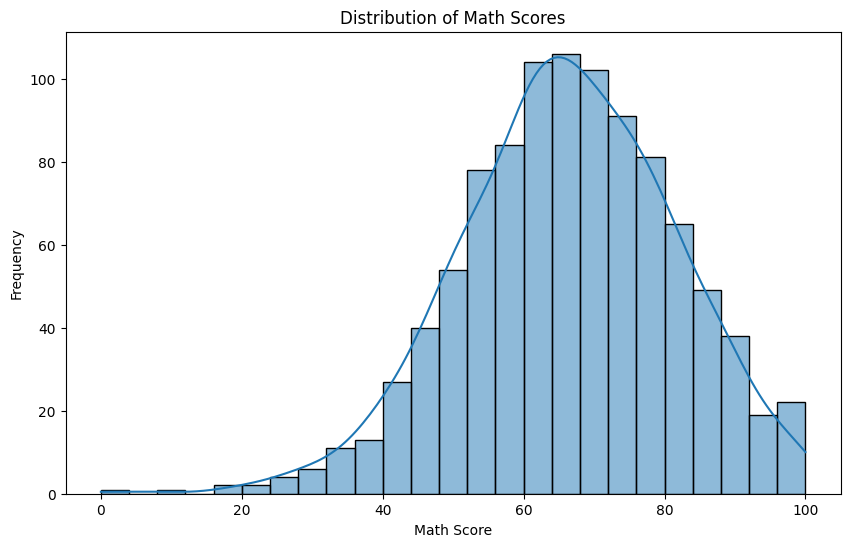

C:\Users\AKANKSHA\AppData\Local\Temp\ipykernel_28392\2718962526.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='math score', data=df, palette=['blue','orange'])


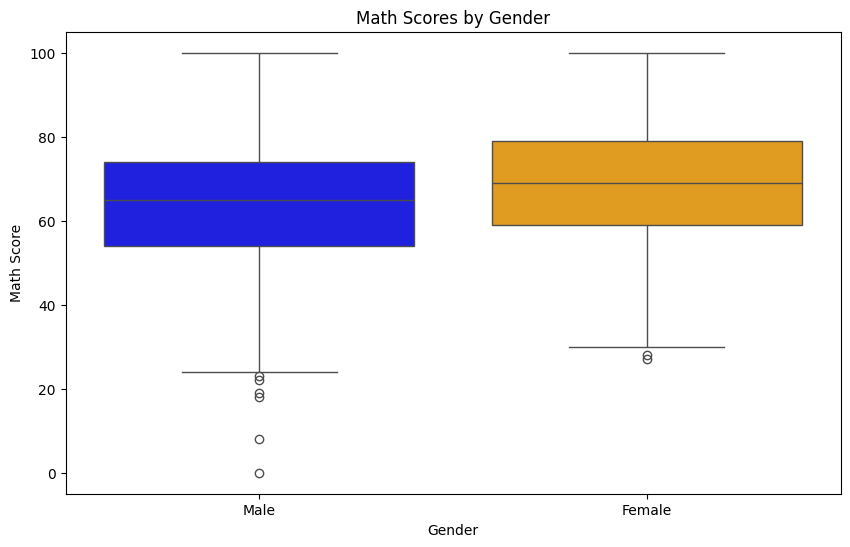

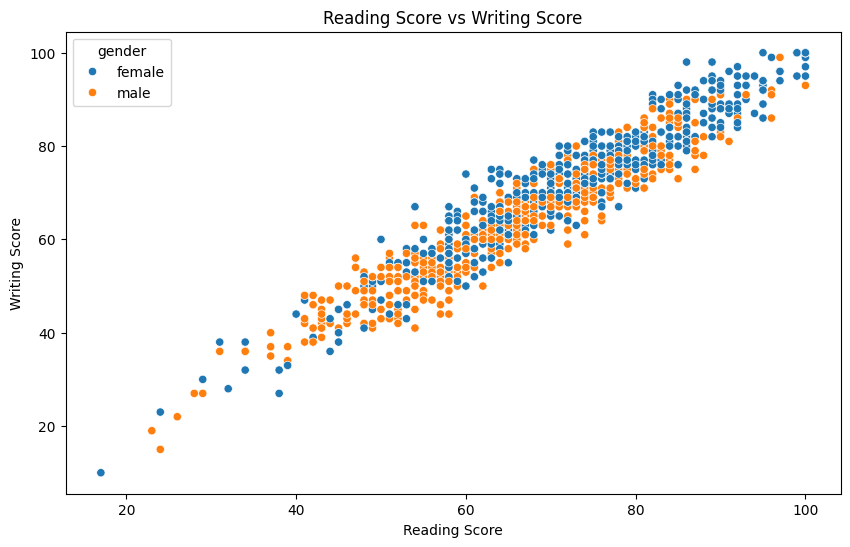

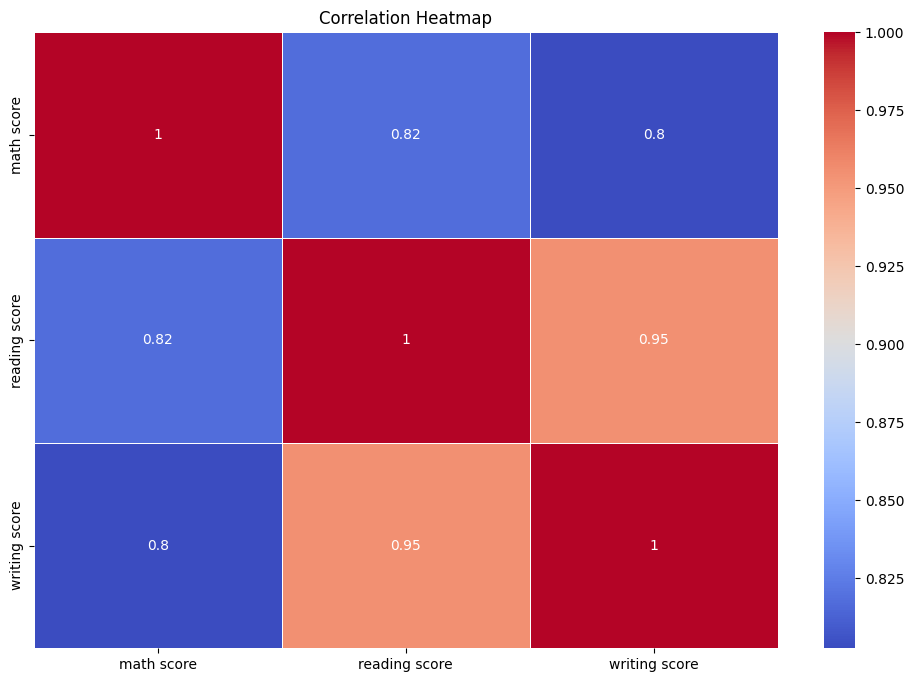

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.histplot(df['math score'],kde=True)
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.show()

# sns.boxplot(data=df,x="gender",y="math score")
# plt.xlabel("Gender")
# plt.ylabel("Math Score")
# plt.title("Math Scores by Gender")
# plt.xticks([0,1],['Male','Female'])
# plt.show()


# Box plot of math scores by gender
plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='math score', data=df, palette=['blue','orange'])
plt.title('Math Scores by Gender')
plt.xlabel('Gender')
plt.ylabel('Math Score')
plt.xticks([0, 1], ['Male', 'Female'])
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x='reading score',y='writing score',data=df,hue='gender')
plt.title("Reading Score vs Writing Score")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.show()

# plt.figure(figsize=(12,8))
# sns.heatmap(df.corr(),annot=True,cmap='coolwarm',linewidth=0.5)
# plt.title("Correlation heatmap")
# plt.show()
# Heatmap of correlations
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

| Colormap | Description           |
| -------- | --------------------- |
| coolwarm | Blue ↔ Red            |
| viridis  | Purple → Yellow       |
| plasma   | Dark purple → Yellow  |
| magma    | Black → Orange        |
| YlGnBu   | Yellow → Green → Blue |


## Step 5: Descriptive Statistics
Calculate and interpret measures of central tendency and dispersion.
Summarize key statistics for numerical variables.

In [43]:
print(df.describe())
mean_math_score=df['math score'].mean()
median_math_score=df['math score'].median()
std_math_score=df['math score'].std()
print("Mean Maths Score:",mean_math_score)
print("Median of Maths Score:",median_math_score)
print("Standard Deviation of Maths Score:",std_math_score)


       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000
Mean Maths Score: 66.089
Median of Maths Score: 66.0
Standard Deviation of Maths Score: 15.16308009600945


## Step 6: Identify Patterns and Relationships
Use correlation analysis to identify relationships between variables.
Perform bivariate and multivariate analyses.

In [45]:
a=df['math score'].corr(df['reading score'])
print("Correlation between reading and math scores:",a)
b=df.groupby(['parental level of education','gender'])[['math score','reading score','writing score']].mean().reset_index() #reset_index() normal numbering returns
print(b)

Correlation between reading and math scores: 0.8175796636720544
   parental level of education  gender  math score  reading score  \
0           associate's degree  female   65.250000      74.120690   
1           associate's degree    male   70.764151      67.433962   
2            bachelor's degree  female   68.349206      77.285714   
3            bachelor's degree    male   70.581818      68.090909   
4                  high school  female   59.351064      68.202128   
5                  high school    male   64.705882      61.480392   
6              master's degree  female   66.500000      76.805556   
7              master's degree    male   74.826087      73.130435   
8                 some college  female   65.406780      73.550847   
9                 some college    male   69.009259      64.990741   
10            some high school  female   59.296703      69.109890   
11            some high school    male   67.840909      64.693182   

    writing score  
0       74.000000 

## Step 7: Outlier Detection
Identify and handle outliers using visualizations and statistical methods.

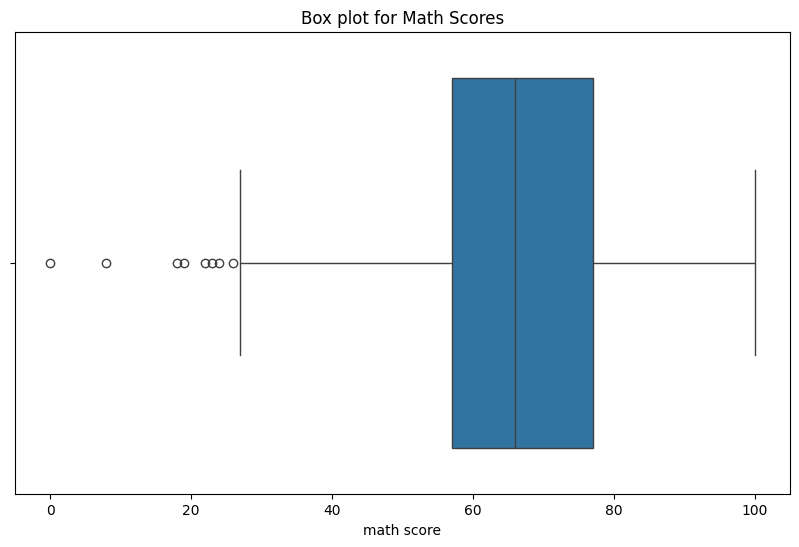

     gender race/ethnicity parental level of education         lunch  \
17   female        group B            some high school  free/reduced   
59   female        group C            some high school  free/reduced   
145  female        group C                some college  free/reduced   
338  female        group B            some high school  free/reduced   
466  female        group D          associate's degree  free/reduced   
787  female        group B                some college      standard   
842  female        group B                 high school  free/reduced   
980  female        group B                 high school  free/reduced   

    test preparation course  math score  reading score  writing score  
17                     none          18             32             28  
59                     none           0             17             10  
145                    none          22             39             33  
338                    none          24             38         

In [47]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['math score'])
plt.title("Box plot for Math Scores")
plt.show()
q1=df['math score'].quantile(0.25)
q3=df['math score'].quantile(0.75)
iqr=q3-q1
outliers=df[(df['math score']<(q1-1.5*iqr))|(df['math score']> (q3+1.5*iqr))]
print(outliers)

In [50]:
pip install scipy

   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.5 MB ? eta -:--:--
    --------------------------------------- 0.5/36.5 MB 1.5 MB/s eta 0:00:24
   - -------------------------------------- 1.0/36.5 MB 2.0 MB/s eta 0:00:18
   -- ------------------------------------- 1.8/36.5 MB 2.5 MB/s eta 0:00:15
   --- ------------------------------------ 2.9/36.5 MB 3.0 MB/s eta 0:00:12
   ---- ----------------------------------- 3.9/36.5 MB 3.4 MB/s eta 0:00:10
   ----- ---------------------------------- 4.7/36.5 MB 3.6 MB/s eta 0:00:09
   ----- ---------------------------------- 5.2/36.5 MB 3.3 MB/s eta 0:00:10
   ------ --------------------------------- 5.8/36.5 MB 3.3 MB/s eta 0:00:10
   ------- -------------------------------- 6.6/36.5 MB 3.3 MB/s eta 0:00:10
   ------- -------------------------------- 7.1/36.5 MB 3.2 MB/s eta 0:00:10
   -------- ------------------------------- 7.3/36.5 MB 3.1 MB/s eta 0:00:10
   -------- -


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 8: Hypothesis Testing
Formulate hypotheses based on initial observations and test them using statistical methods.

In [51]:
from scipy.stats import ttest_ind

# Hypothesis: Male and female students have different math scores
male_math_scores = df[df['gender'] == 0]['math score']
female_math_scores = df[df['gender'] == 1]['math score']

t_stat, p_value = ttest_ind(male_math_scores, female_math_scores)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: nan, P-value: nan


C:\Users\AKANKSHA\AppData\Local\Temp\ipykernel_28392\1312906282.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value = ttest_ind(male_math_scores, female_math_scores)


## Step 9: Summarize Findings
Compile insights and key findings from the EDA into a report.
Use visualizations and statistical summaries to present your results.

<Axes: >

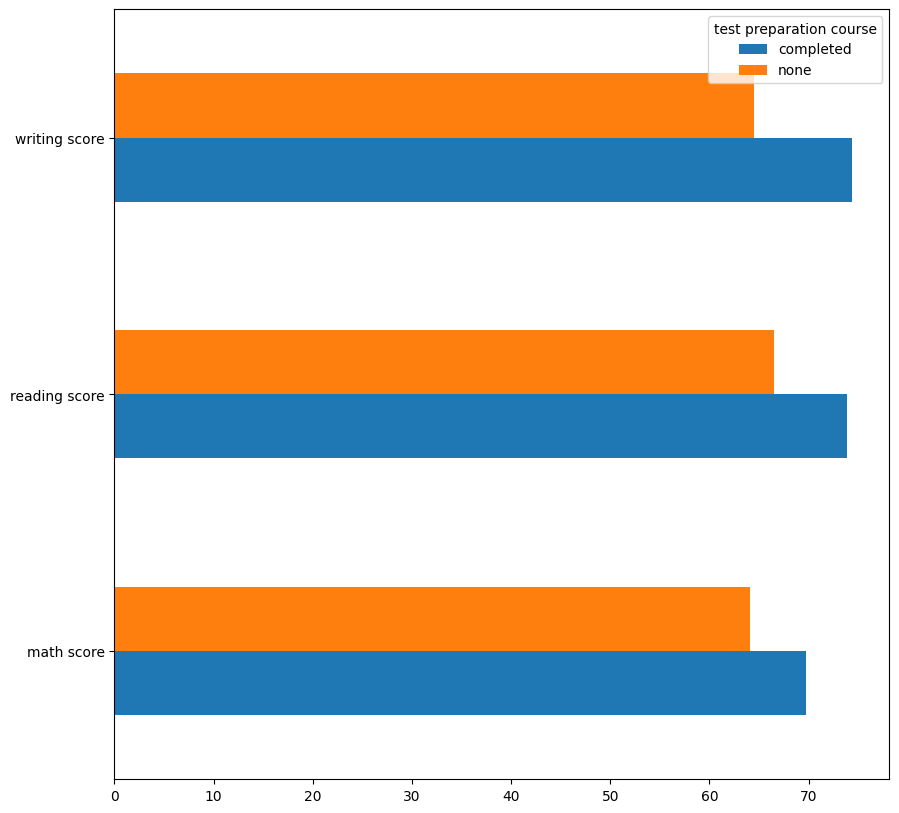

In [52]:
df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean().T.plot(kind='barh', figsize=(10,10))